# Task 1: Universal Multi-Corruption Restoration (VAE Simple Baseline)

This notebook implements the **Simple VAE Baseline** for Task 1 as specified in **Plan 4 §2** and **Plan 6 §1**.

### Workflow:
1. **Config & Environment**: Device detection and hyperparameter definitions.
2. **Data Pipeline**: Oxford-IIIT Pet dataset with runtime corruptions (clean, salt-pepper, blur, occlusion at 25% each).
3. **Model**: Symmetric Convolutional VAE (`ConvVAE`) with GroupNorm and strided convs (no skip connections in baseline).
4. **Loss**: Composite reconstruction loss ($\alpha \cdot \text{L1} + (1-\alpha) \cdot (1-\text{SSIM})$) + fixed small $\beta \cdot \text{KL}$.
5. **Training & Validation**: Multi-epoch training loop with automatic checkpointing (`latest.pt` & `best.pt`).
6. **Evaluation & Visualization**: Visual inspection grid and transition gate checks before proceeding to Optuna.

In [ ]:
# 1. Configuration & Hyperparameters
import os

# Set TINY_RUN=True for quick 2-epoch CPU/GPU sanity checks (Plan 4 §1)
TINY_RUN = False
TINY_SIZE = 50

# Training hyperparameters (Plan 7 reference)
BATCH_SIZE = 32
LR = 1e-3
LATENT_DIM = 128
BASE_CHANNELS = 32
DROPOUT = 0.1
ALPHA = 0.8       # Reconstruction loss: alpha*L1 + (1-alpha)*(1-SSIM)
BETA = 0.001      # KL divergence weight
EPOCHS = 2 if TINY_RUN else 15
SEED = 42

# Experiment tracking
USE_WANDB = True
WANDB_PROJECT = "genai-assignment"
WANDB_RUN_NAME = "task1_vae_simple_baseline"

In [17]:
# 2. Imports and Environment Setup
import sys
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Ensure research root is in sys.path
RESEARCH_ROOT = Path("..").resolve()
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

from constants import PET_IMAGES_DIR, CHECKPOINTS_MANIFEST
from src.device_utils import get_device, device_report
from src.datasets import PetDataset
from src.models_vae import ConvVAE
from src.train_loop import train_one_epoch_vae, validate_vae, set_seed
from src.checkpoint_utils import create_checkpoint_dict, save_checkpoint

set_seed(SEED)
print("[Setup] Imports successful. Manifest path:", CHECKPOINTS_MANIFEST)

[Setup] Imports successful. Manifest path: /run/media/hmz-gul/01DB003D88B96CA0/Semesters-Data/sem-7/Gen-AI/genai-assignment/research/checkpoints_manifest.json


In [10]:
# 3. Device Check
device = get_device(verbose=True)
report = device_report()
print(f"[Device Report] Type: {report['device_type']}, Name: {report['device_name']}")
if torch.cuda.is_available():
    print(f"[GPU Memory] Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

[device] No GPU detected — using CPU
[Device Report] Type: cpu, Name: CPU


In [11]:
# 4. Data Loading
mode_train = "tiny" if TINY_RUN else "train"
mode_val = "tiny" if TINY_RUN else "val"

train_dataset = PetDataset(mode=mode_train, corruption_mode="all", tiny_size=TINY_SIZE, seed=SEED)
val_dataset = PetDataset(mode=mode_val, corruption_mode="all", tiny_size=TINY_SIZE, seed=SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print(f"[Data] Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print(f"[Data] Batches per epoch: Train={len(train_loader)}, Val={len(val_loader)}")

[Data] Train samples: 50, Val samples: 50
[Data] Batches per epoch: Train=2, Val=2


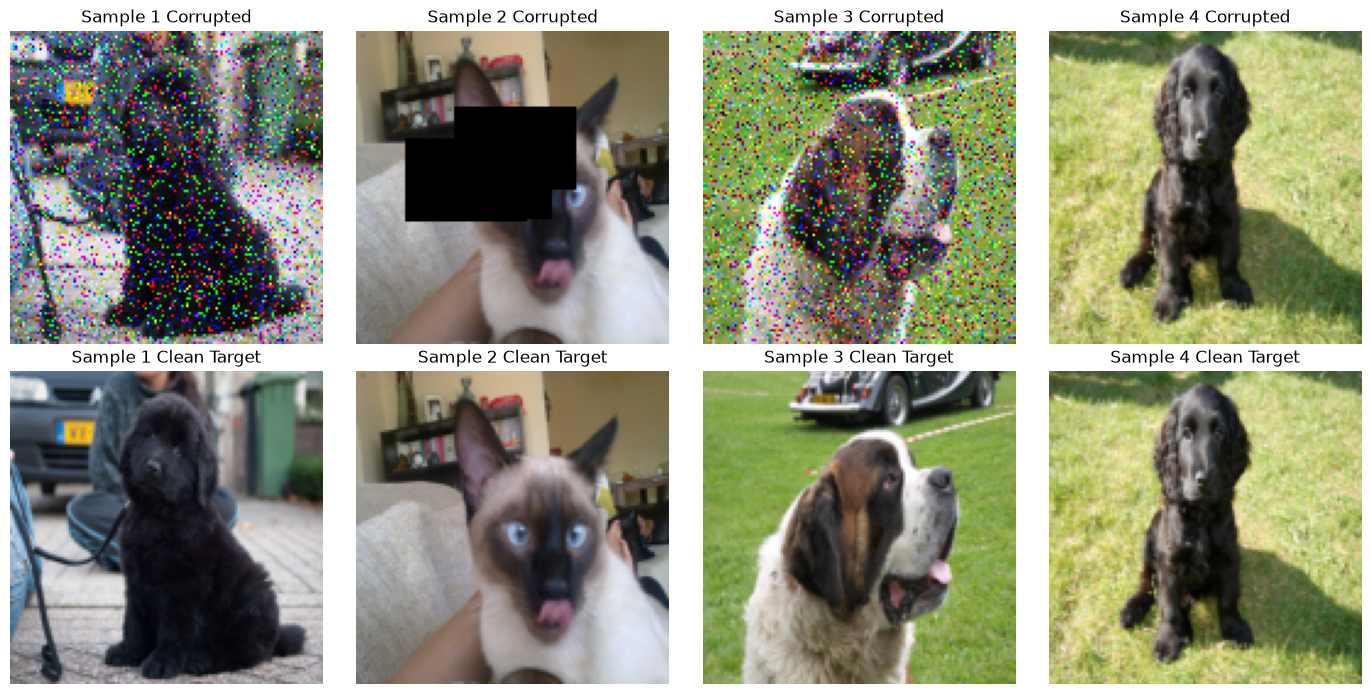

In [12]:
# 5. Data Inspection: Sample Pairs
sample_corrupted, sample_clean = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    c_img = sample_corrupted[i].permute(1, 2, 0).cpu().numpy()
    cl_img = sample_clean[i].permute(1, 2, 0).cpu().numpy()
    
    axes[0, i].imshow(c_img.clip(0, 1))
    axes[0, i].set_title(f"Sample {i+1} Corrupted")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(cl_img.clip(0, 1))
    axes[1, i].set_title(f"Sample {i+1} Clean Target")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# 6. Model & Optimizer Initialization
model = ConvVAE(
    in_channels=3,
    base_channels=BASE_CHANNELS,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
    use_skip=False  # Baseline: no skip connections (Plan 6 §1.2)
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Model] ConvVAE initialized with {total_params:,} trainable parameters.")

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

# Optional Weights & Biases Logging
if USE_WANDB:
    import wandb
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            "task": "task1_universal_vae",
            "device": report["device_type"],
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "latent_dim": LATENT_DIM,
            "alpha": ALPHA,
            "beta": BETA,
            "epochs": EPOCHS,
        }
    )

[Model] ConvVAE initialized with 4,306,179 trainable parameters.


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/hmz-gul/.netrc.
wandb: Currently logged in as: i230510 (i230510-fast-nuces-islamabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [14]:
# 7. Training & Validation Loop
history = {
    "train_loss": [], "recon_loss": [], "kl_loss": [], "ssim": [],
    "val_loss": [], "val_recon": [], "val_kl": [], "val_ssim": []
}

best_val_loss = float("inf")
checkpoint_dir = RESEARCH_ROOT / "checkpoints"

print(f"--- Starting Training ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch_vae(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        alpha=ALPHA,
        beta=BETA,
        scaler=scaler
    )
    val_metrics = validate_vae(
        model=model,
        loader=val_loader,
        device=device,
        alpha=ALPHA,
        beta=BETA
    )
    
    # Record history
    for k, v in train_metrics.items():
        history[k].append(v)
    for k, v in val_metrics.items():
        history[k].append(v)
        
    val_loss = val_metrics["val_loss"]
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        
    # Save checkpoint
    ckpt_dict = create_checkpoint_dict(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        val_loss=val_loss,
        random_seed=SEED,
        extra_metadata={"alpha": ALPHA, "beta": BETA, "latent_dim": LATENT_DIM}
    )
    save_checkpoint(
        checkpoint_dir=checkpoint_dir,
        prefix="task1_universal_ae",
        ckpt_dict=ckpt_dict,
        is_best=is_best,
        task_name="task1",
        phase_name="simple",
        device_name=report["device_name"]
    )
    
    if USE_WANDB:
        wandb.log({**train_metrics, **val_metrics, "epoch": epoch})
        
    print(
        f"Epoch [{epoch:02d}/{EPOCHS:02d}] "
        f"Train Loss: {train_metrics['train_loss']:.4f} (Recon: {train_metrics['recon_loss']:.4f}, KL: {train_metrics['kl_loss']:.4f}) | "
        f"Val Loss: {val_loss:.4f} (SSIM: {val_metrics['val_ssim']:.4f}) {'*Best*' if is_best else ''}"
    )

print("--- Training Completed ---")
if USE_WANDB:
    wandb.finish()

--- Starting Training (2 Epochs) ---
Epoch [01/02] Train Loss: 0.4070 (Recon: 0.3269, KL: 80.1812) | Val Loss: 0.4008 (SSIM: 0.3362) *Best*
Epoch [02/02] Train Loss: 0.3621 (Recon: 0.3128, KL: 49.3513) | Val Loss: 0.3345 (SSIM: 0.3389) *Best*
--- Training Completed ---


epoch,▁█
kl_loss,█▁
recon_loss,█▁
ssim,▁█
train_loss,█▁
val_kl,█▁
val_loss,█▁
val_recon,█▁
val_ssim,▁█
epoch,2
kl_loss,49.35135


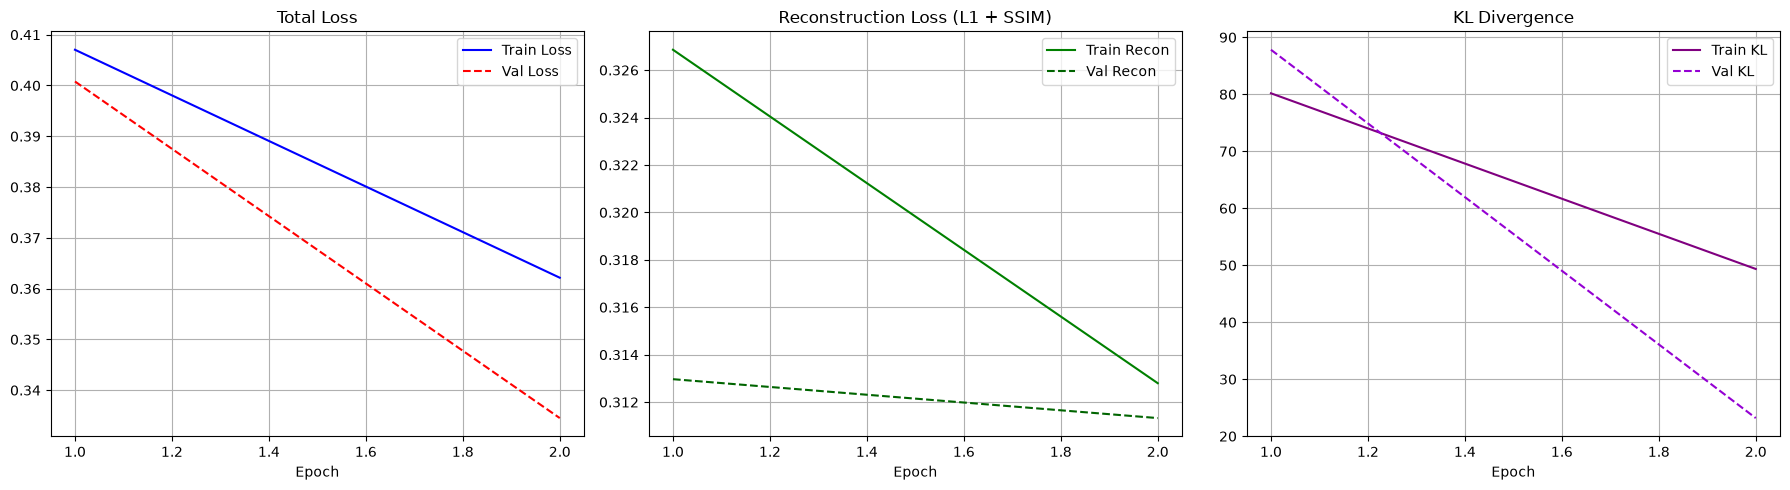

In [15]:
# 8. Learning Curves
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="blue")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history["recon_loss"], label="Train Recon", color="green")
axes[1].plot(epochs_range, history["val_recon"], label="Val Recon", color="darkgreen", linestyle="--")
axes[1].set_title("Reconstruction Loss (L1 + SSIM)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_range, history["kl_loss"], label="Train KL", color="purple")
axes[2].plot(epochs_range, history["val_kl"], label="Val KL", color="darkviolet", linestyle="--")
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x7f78a05c2560>:
Traceback (most recent call last):
  File "/run/media/hmz-gul/01DB003D88B96CA0/Semesters-Data/sem-7/Gen-AI/genai-assignment/.conda/lib/python3.14/site-packages/torch/utils/data/dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "/run/media/hmz-gul/01DB003D88B96CA0/Semesters-Data/sem-7/Gen-AI/genai-assignment/.conda/lib/python3.14/site-packages/torch/utils/data/dataloader.py", line 1650, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


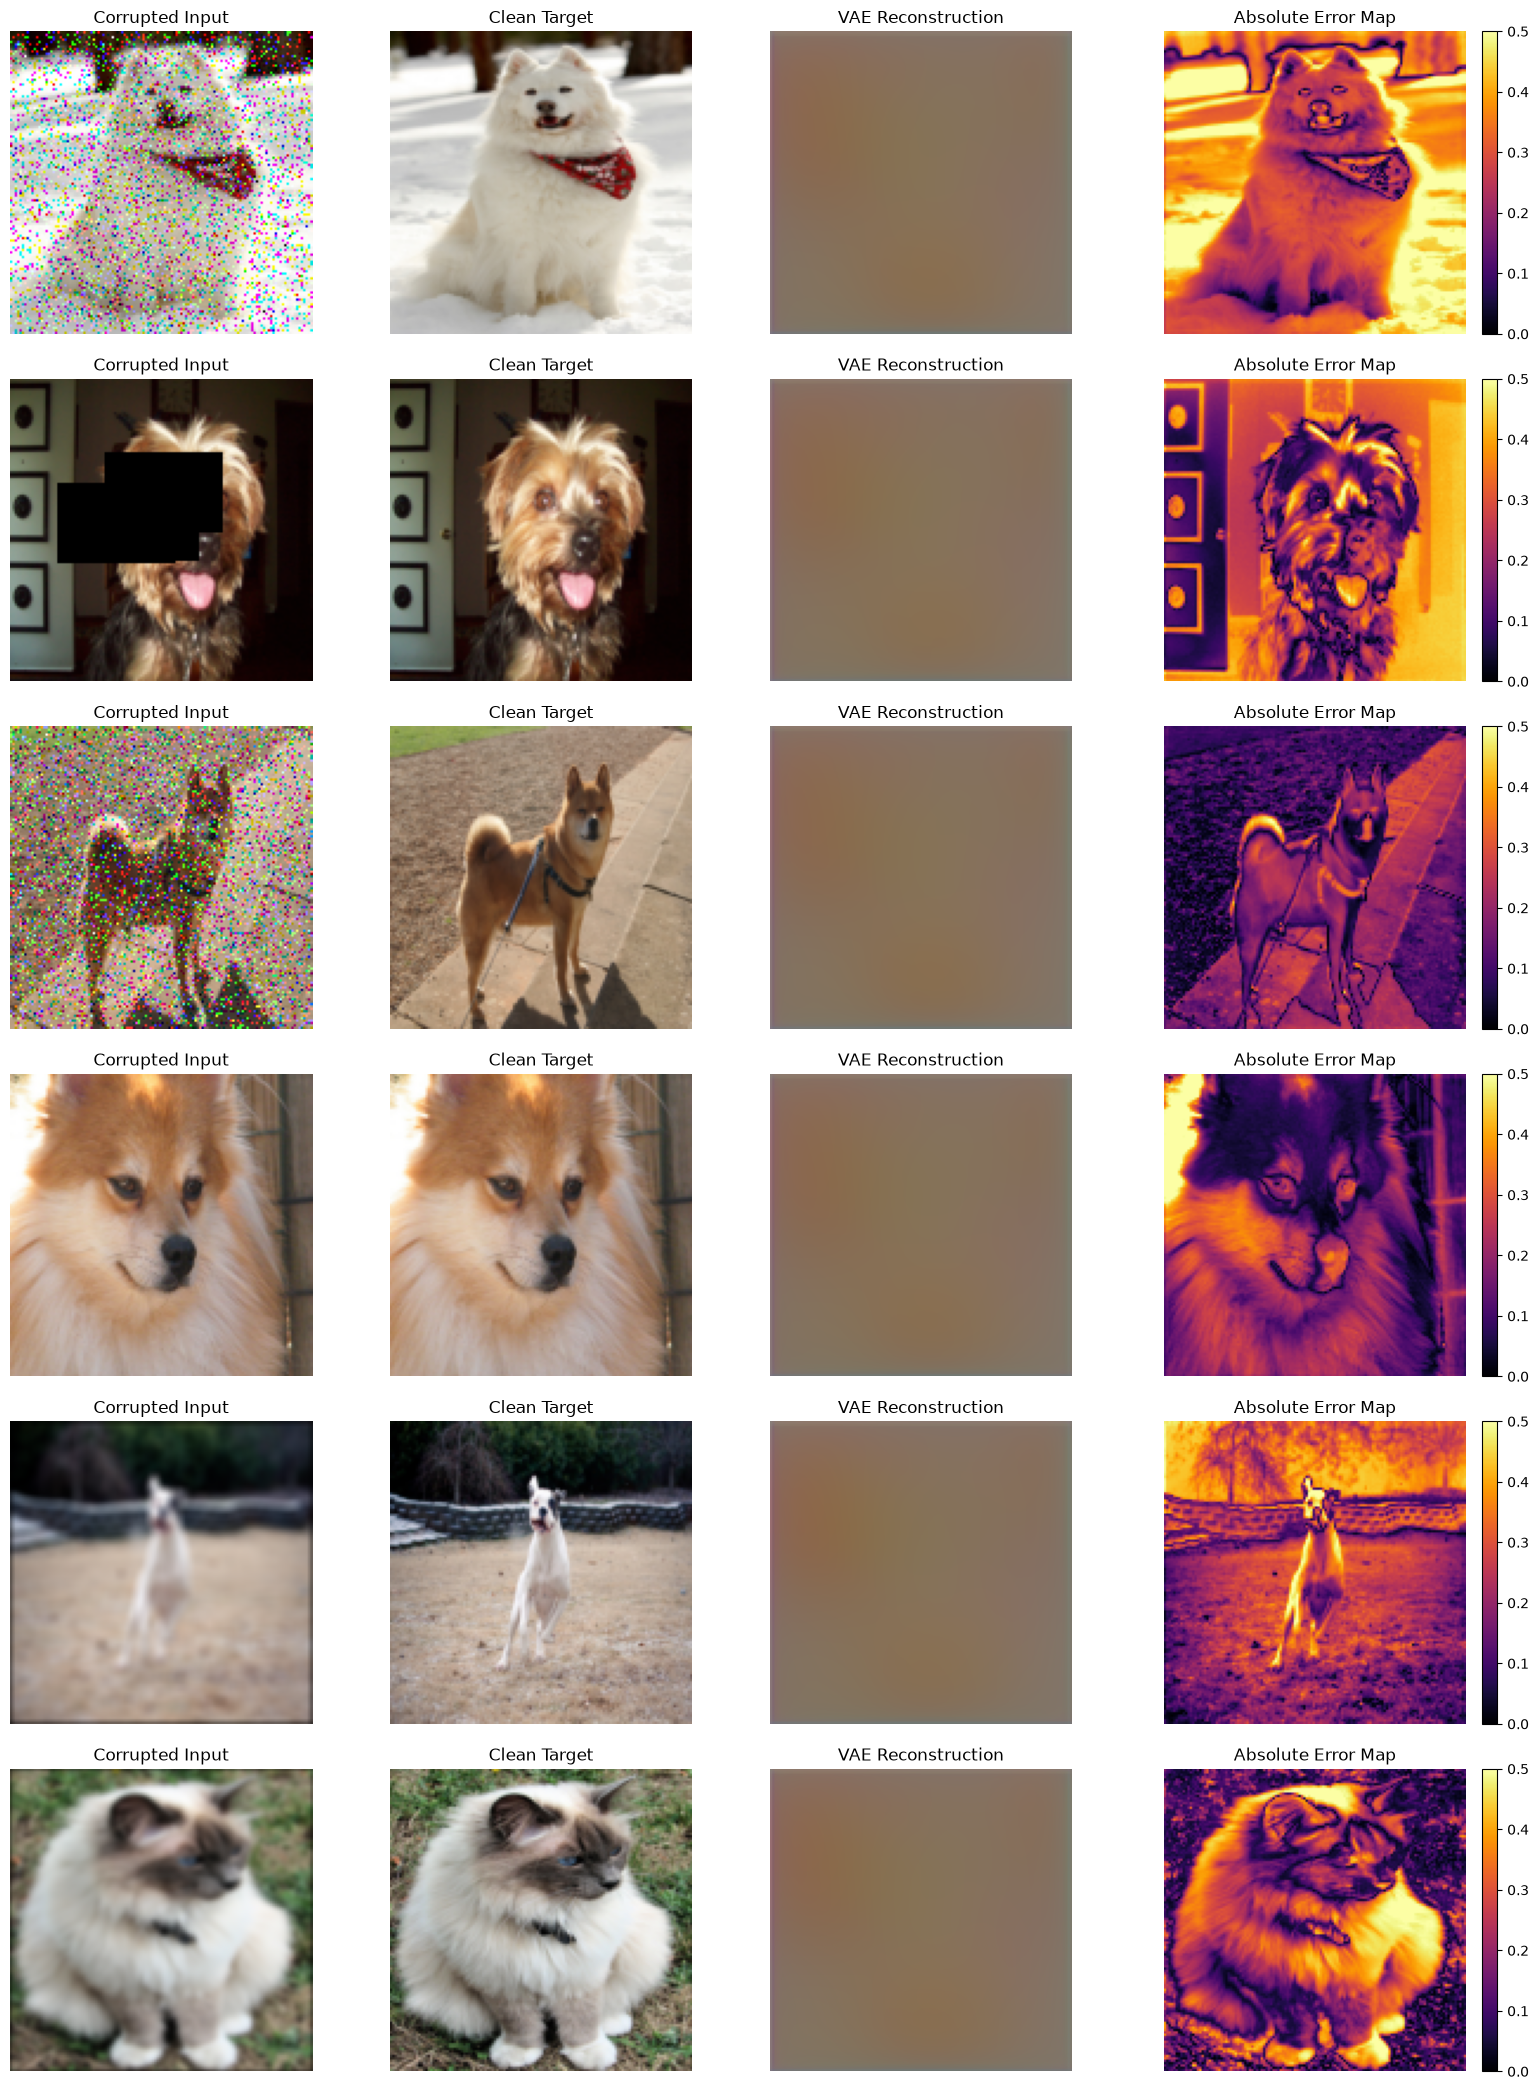

In [18]:
# 9. Qualitative Visual Inspection Grid (Plan 6 §1.3)
model.eval()
val_batch_corrupted, val_batch_clean = next(iter(val_loader))

with torch.no_grad():
    recon_batch, _, _ = model(val_batch_corrupted.to(device))
    recon_batch = recon_batch.cpu()

num_display = min(6, len(val_batch_corrupted))
fig, axes = plt.subplots(num_display, 4, figsize=(16, 3.5 * num_display))

for i in range(num_display):
    c_in = val_batch_corrupted[i].permute(1, 2, 0).numpy().clip(0, 1)
    target = val_batch_clean[i].permute(1, 2, 0).numpy().clip(0, 1)
    output = recon_batch[i].permute(1, 2, 0).numpy().clip(0, 1)
    error_map = np.abs(target - output).mean(axis=-1)  # Grayscale error

    axes[i, 0].imshow(c_in)
    axes[i, 0].set_title("Corrupted Input")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(target)
    axes[i, 1].set_title("Clean Target")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(output)
    axes[i, 2].set_title("VAE Reconstruction")
    axes[i, 2].axis("off")

    im_err = axes[i, 3].imshow(error_map, cmap="inferno", vmin=0, vmax=0.5)
    axes[i, 3].set_title("Absolute Error Map")
    axes[i, 3].axis("off")
    fig.colorbar(im_err, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 10. Transition Gate Checklist (Plan 6 §1.4)
Before proceeding to `task1_vae_optuna.ipynb`, confirm that all criteria pass:
- [ ] Loss curves decrease reliably with no NaNs.
- [ ] Reconstructions visually reasonable across all 4 conditions (clean, salt, blur, occlusion).
- [ ] KL term is not collapsed to ~0 throughout training.
- [ ] Checkpoint save/reload verified (`task1_universal_ae_best.pt` exists and loads cleanly).